In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import warnings
import pickle
import pandas as pd
import random
import numpy as np
from tqdm.auto import tqdm
from scipy.special import xlogy
import networkx as nx
import GCRCatalogs
import healpy as hp
from GCR import GCRQuery
import matplotlib.pyplot as plt

import lsst
import lsst.daf.persistence as dafPersist
import desc_dc2_dm_data
import lsst.geom
import lsst.afw.display as afwDisplay
import lsst.afw.display.rgb as rgb
from astropy.wcs import WCS

/opt/lsst/software/stack/python/miniconda3-4.7.10/envs/lsst-scipipe-4d7b902/lib/python3.7/site-packages/GCRCatalogs/register.py:160: UserWarning: Site determined from env variable DESC_GCR_SITE = nersc, which differs from node name login16.chn
  self._DESC_SITE_ENV, site_from_env, site_from_socket
/opt/lsst/software/stack/python/miniconda3-4.7.10/envs/lsst-scipipe-4d7b902/lib/python3.7/site-packages/desc_dc2_dm_data/site.py:28: UserWarning: Site determined from env variable DESC_GCR_SITE = nersc, which differs from node name login16.chn
  _DESC_SITE_ENV, site_from_env, site_from_socket


In [3]:
sys.path.append('../')

In [4]:
import friendly.ellipses as ellipses
import friendly.entropy as entropy
import friendly.gaussians as gaussians
import friendly.graphs as graphs
import friendly.matching as matching

In [5]:
warnings.filterwarnings('ignore')

### 1. Load cosmoDC2 and DC2object with few cuts

In [6]:
tract = 4026

In [ ]:
quantities_true = ['ra', 'dec', 'mag_i', 'size_true', 'size_minor_true', 'position_angle_true']

quantities_obj = ['ra', 'dec', 'blendedness', 'mag_i_cModel', 'x', 'y', 'Ixx_pixel_i', 'Iyy_pixel_i', 'Ixy_pixel_i', 'patch', 'psf_fwhm_i']

In [ ]:
filters_true = [(np.isfinite, 'mag_i'), 'mag_i>18', 'mag_i<29', (np.isfinite,'ellipticity_1_true'), (np.isfinite,'ellipticity_2_true'), 
                (np.isfinite,'redshift'), (np.isfinite, 'convergence'), (np.isfinite, 'mag_i'), (np.isfinite, 'shear_1'),
                (np.isfinite, 'shear_2')]

filters_obj = [(np.isfinite, 'mag_i_cModel'), 'mag_i_cModel > 18', 'mag_i_cModel < 26.5', (np.isfinite, 'mag_i_cModel'), 
               (np.isfinite,'ext_shapeHSM_HsmShapeRegauss_e1'), (np.isfinite,'ext_shapeHSM_HsmShapeRegauss_e2'), 
               (np.isfinite, 'ext_shapeHSM_HsmShapeRegauss_sigma'), ('ext_shapeHSM_HsmShapeRegauss_flag == 0'),
               (np.isfinite, 'photoz_mean'), (np.isfinite, 'blendedness')]

In [ ]:
cosmodc2 = GCRCatalogs.load_catalog('cosmoDC2_v1.1.4_image') #truth catalog
dc2 = GCRCatalogs.load_catalog('dc2_object_run2.2i_dr6_with_addons') #object catalog

In [ ]:
object_data = pd.DataFrame(dc2.get_quantities(quantities_obj,
                                  filters=['extendedness>0', 'clean']+filters_obj,
                                  native_filters=[f'tract=={tract}']))

In [ ]:
eps = 10/3600 # 10 arcsec
max_ra = np.nanmax(object_data['ra']) + eps
min_ra = np.nanmin(object_data['ra']) - eps
max_dec = np.nanmax(object_data['dec']) + eps
min_dec = np.nanmin(object_data['dec']) - eps
pos_filters = [f'ra >= {min_ra}',f'ra <= {max_ra}', f'dec >= {min_dec}', f'dec <= {max_dec}']

vertices = hp.ang2vec(np.array([min_ra, max_ra, max_ra, min_ra]),
                      np.array([min_dec, min_dec, max_dec, max_dec]), lonlat=True)
ipix = hp.query_polygon(32, vertices, inclusive=True)
healpix_filter = GCRQuery((lambda h: np.isin(h, ipix, True), "healpix_pixel"))

In [ ]:

truth_data = pd.DataFrame(cosmodc2.get_quantities(quantities_true, filters=filters_true+pos_filters, 
                                      native_filters=healpix_filter))

### 2. Friends-of-Friends groups with linking length = 2''

In [ ]:

need 'ra', 'dec'
FoF_groups = matching.FoF_matching(truth_data, object_data, 2.) #takes time

In [ ]:
FoF_groups[:10]

### 3. Select one random group

In [127]:
group = [[],[]]
n = 3 #choose the number of galaxies
m = 2 #choose the number of objects

while (len(group[0]) != n) | (len(group[1]) != m): #choose which system you want to study
    group = FoF_groups[random.randint(0,len(FoF_groups))]

In [87]:
truth_data['mag_i'][group[0]]

75877     22.722223
128185    24.315229
174588    21.939030
Name: mag_i, dtype: float64

In [88]:
object_data['mag_i_cModel'][group[1]]

260008    21.446538
260009    24.316771
Name: mag_i_cModel, dtype: float64

### 4. Object ellipse parameters

In [89]:
# need 'x', 'y', 'Ixx_pixel_i', 'Iyy_pixel_i', 'Ixy_pixel_i'
obj_infos = ellipses.ellipse_infos(group, truth_data, object_data, dc2_type='object')

In [90]:
obj_infos

,x,y,a,b,theta
260008,11517.075474,24130.569469,3.602944,2.569058,47.073933
260009,11525.315957,24126.720511,3.375924,2.492206,21.097590


In [91]:
obj_param = ellipses.ellipse_parameters(obj_infos)

In [92]:
obj_param

,A,B,C,D,E,F
260008,10.021408,9.559855,-3.182215,-38628.651893,-194034.945550,5.127063e+09
260009,6.883008,10.724943,-1.741532,-37311.380808,-238685.990589,6.188736e+09


### 5. Galaxy ellipse parameters

In [93]:
# need 'psf_fwhm_i', 'size_true', 'size_minor_true', 'position_angle_true', 'ra', 'dec'
gal_infos = ellipses.ellipse_infos(group, truth_data, object_data, dc2_type='galaxy')

In [94]:
gal_infos

,x,y,a,b,theta
75877,11514.066227,24127.491187,3.082866,3.064619,132.338298
128185,11525.533465,24126.952389,2.755355,2.525131,43.789458
174588,11517.425240,24130.871285,2.706316,2.660435,68.436973


In [95]:
gal_param = ellipses.ellipse_parameters(gal_infos)

In [96]:
gal_param

,A,B,C,D,E,F
75877,9.453182,9.442775,0.055845,-110191.966485,-228473.471238,6.781249e+09
128185,6.958457,7.009812,-0.607303,-65547.557287,-162125.910306,4.667075e+09
174588,7.290889,7.111175,-0.084163,-81941.339646,-170629.511808,5.061192e+09


### Plot the ellipses

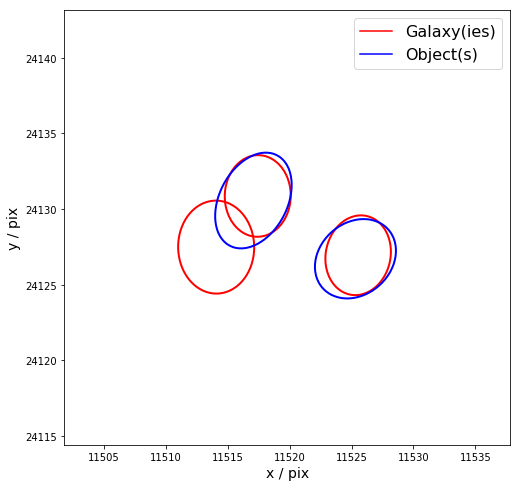

In [97]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)

rough_size = 4 * np.sqrt(gal_infos['a'][group[0][0]] * gal_infos['b'][group[0][0]])
idx1 = group[0]
idx2 = group[1]

for n in range(len(idx1)):
    p_gal = [gal_param[k][idx1[n]] for k in gal_param.keys()]
    ellipses.plot_shape(gal_infos['x'][idx1[n]], gal_infos['y'][idx1[n]], rough_size, p_gal, c='r', ls='-', ax=ax)    

for m in range(len(idx2)):
    p_obj = [obj_param[k][idx2[m]] for k in obj_param.keys()]
    ellipses.plot_shape(obj_infos['x'][idx2[m]], obj_infos['y'][idx2[m]], rough_size, p_obj, c='b', ls='-', ax=ax)

ax.set_xlabel('x / pix', fontsize=14)
ax.set_ylabel('y / pix', fontsize=14)

ax.plot([], [], 'r', label='Galaxy(ies)')
ax.plot([], [], 'b', label='Object(s)')
ax.legend(prop={'size':16})

### 6. NetworkX graph

In [98]:
infos = pd.merge(gal_infos.T, obj_infos.T, how='outer', left_index=True, right_index=True)

In [99]:
infos

,75877,128185,174588,260008,260009
x,11514.066227,11525.533465,11517.425240,11517.075474,11525.315957
y,24127.491187,24126.952389,24130.871285,24130.569469,24126.720511
a,3.082866,2.755355,2.706316,3.602944,3.375924
b,3.064619,2.525131,2.660435,2.569058,2.492206
theta,132.338298,43.789458,68.436973,47.073933,21.097590


In [100]:
param = pd.merge(gal_param.T, obj_param.T, how='outer', left_index=True, right_index=True)

In [101]:
param

,75877,128185,174588,260008,260009
A,9.453182e+00,6.958457e+00,7.290889e+00,1.002141e+01,6.883008e+00
B,9.442775e+00,7.009812e+00,7.111175e+00,9.559855e+00,1.072494e+01
C,5.584511e-02,-6.073032e-01,-8.416314e-02,-3.182215e+00,-1.741532e+00
D,-1.101920e+05,-6.554756e+04,-8.194134e+04,-3.862865e+04,-3.731138e+04
E,-2.284735e+05,-1.621259e+05,-1.706295e+05,-1.940349e+05,-2.386860e+05
F,6.781249e+09,4.667075e+09,5.061192e+09,5.127063e+09,6.188736e+09


In [102]:
link_type='ellipse'

In [103]:
G = graphs.NetworkX_graph(group, truth_data, object_data, infos, param, link_type)

In [104]:
list(G.nodes(data=True))

[(75877,
  {'galaxy': True,
   'magnitude': 22.72222271931155,
   'purity': 0.49529509905223196}),
 (128185, {'galaxy': True, 'magnitude': 24.31522904561232, 'purity': 1.0}),
 (174588,
  {'galaxy': True,
   'magnitude': 21.939029537815358,
   'purity': 0.5628864268071593}),
 (260008,
  {'galaxy': False,
   'magnitude': 21.446538482637205,
   'blendedness': 0.006690199602556901,
   'purity': 1.0}),
 (260009,
  {'galaxy': False,
   'magnitude': 24.316771438441016,
   'blendedness': 0.13563579259194447,
   'purity': 1.0})]

In [105]:
list(G.edges(data=True))

[(75877, 174588, {'overlap_fraction': 0.0439297124600639}),
 (75877, 260008, {'overlap_fraction': 0.13400464756003097}),
 (128185, 260009, {'overlap_fraction': 0.7858197932053177}),
 (174588, 260008, {'overlap_fraction': 0.7499999999999999})]

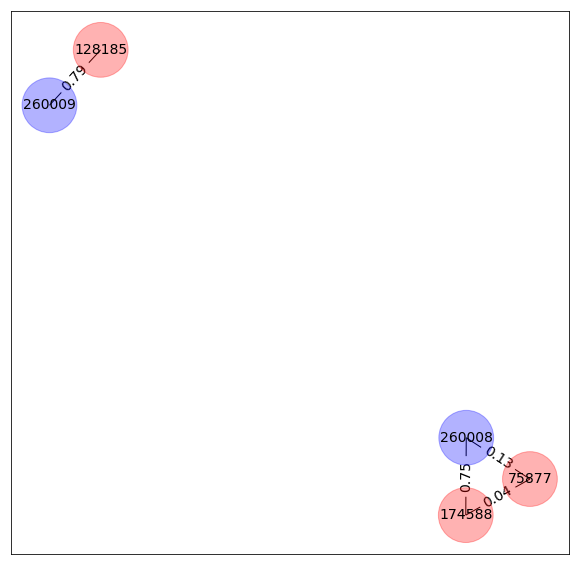

In [106]:
fig = plt.figure(figsize=(10,10))

pos = nx.spring_layout(G, seed=10, weight='overlap')
color_map = ['red' if G.nodes[k]['galaxy'] == True else 'blue' for k in list(G.nodes)]  

nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=3000, node_shape='o', alpha=0.3)
nx.draw_networkx_edges(G, pos)

nx.draw_networkx_labels(G, pos, font_size=14, font_weight='normal')
edge_labels = nx.get_edge_attributes(G, "overlap_fraction")
for k in edge_labels.keys():
    edge_labels[k] = round(edge_labels[k], 2)
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=14)
plt.show()

#### Refine graphs if groups of ellipses don't overlap (optional)

In [107]:
S = graphs.refine_groups(G)

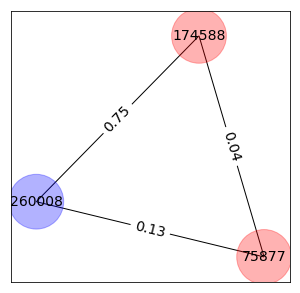

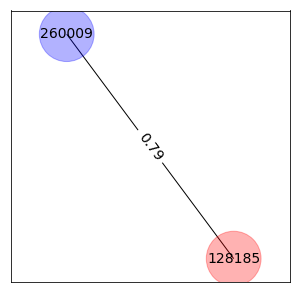

In [108]:
for s in S:
    fig = plt.figure(figsize=(5,5))
    pos = nx.spring_layout(s, seed=10, weight='overlap')
    color_map = ['red' if s.nodes[k]['galaxy'] == True else 'blue' for k in list(s.nodes)]  
    
    nx.draw_networkx_nodes(s, pos, node_color=color_map, node_size=3000, node_shape='o', alpha=0.3)
    nx.draw_networkx_edges(s, pos)
    
    nx.draw_networkx_labels(s, pos, font_size=14, font_weight='normal')
    edge_labels = nx.get_edge_attributes(s, "overlap_fraction")
    for k in edge_labels.keys():
        edge_labels[k] = round(edge_labels[k], 2)
    nx.draw_networkx_edge_labels(s, pos, edge_labels, font_size=14)
    plt.show()

### 7. Add probability of matching and blending entropy

In [109]:
entropy.blending_entropy(G)

In [110]:
list(G.nodes(data=True))

[(75877,
  {'galaxy': True,
   'magnitude': 22.72222271931155,
   'purity': 0.49529509905223196}),
 (128185, {'galaxy': True, 'magnitude': 24.31522904561232, 'purity': 1.0}),
 (174588,
  {'galaxy': True,
   'magnitude': 21.939029537815358,
   'purity': 0.5628864268071593}),
 (260008,
  {'galaxy': False,
   'magnitude': 21.446538482637205,
   'blendedness': 0.006690199602556901,
   'purity': 1.0,
   'proba': {'75877': 0.07548105079669909, '174588': 0.9245189492033009},
   'blending_entropy': 0.2675913453371506}),
 (260009,
  {'galaxy': False,
   'magnitude': 24.316771438441016,
   'blendedness': 0.13563579259194447,
   'purity': 1.0,
   'proba': {'128185': 1.0},
   'blending_entropy': 0.0})]

### 8. Plot DC2 RGB images

In [111]:
object_data['patch'][idx2]

260008    2,6
260009    2,6
Name: patch, dtype: object

In [112]:
dc2_data_version = "2.2i_dr6_wfd"
butler = desc_dc2_dm_data.get_butler(dc2_data_version)
skymap = butler.get('deepCoadd_skyMap')
patch = object_data['patch'][idx2[0]]
dataId = {'tract':tract, 'patch': patch, 'filter':'i'}

In [122]:
size_in_pix = np.round(np.max([np.max(gal_infos['a']), np.max(obj_infos['a']), np.max(gal_infos['b']), np.max(obj_infos['b'])])/0.2) 
if size_in_pix%2 == 1:
    size_in_pix += 1
    
rough_size = 2*np.sqrt(np.max([np.max(gal_infos['a']*gal_infos['b']), np.max(obj_infos['a']*obj_infos['b'])]))

size_in_pix += rough_size + 10

dx_obj = (((object_data['ra'][idx2[0]] - object_data['ra'][idx2]) * np.cos(np.radians( (object_data['dec'][idx2]+object_data['dec'][idx2[0]]) / 2 )) * 3600 / 0.2)) #pixel displacement with respect to the position of the object #1 
dy_obj = ((object_data['dec'][idx2[0]] - object_data['dec'][idx2]) * 3600 / 0.2)

dx_gal = (((object_data['ra'][idx2[0]] - truth_data['ra'][idx1]) * np.cos(np.radians( (truth_data['dec'][idx1]+object_data['dec'][idx2[0]]) / 2 )) * 3600 / 0.2)) #pixel displacement with respect to the position of the object #1 
dy_gal = ((object_data['dec'][idx2[0]] - truth_data['dec'][idx1]) * 3600 / 0.2)

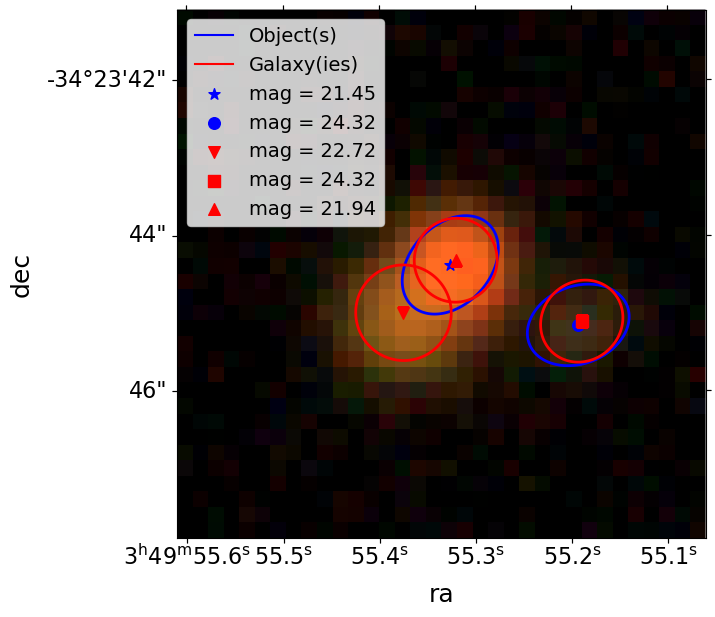

In [126]:
markers = ['*', 'o', 'v', 's', '^', 'P', '*', 'o', 'v']

cutout_size = size_in_pix  # 300 pixels -> about 1 arcmin; use even-number size!!
cutout_extent = lsst.geom.ExtentI(cutout_size, cutout_size)

############################################################################

radec = lsst.geom.SpherePoint(object_data['ra'][idx2[0]], object_data['dec'][idx2[0]], lsst.geom.degrees)

center = skymap.findTract(radec).getWcs().skyToPixel(radec)

if np.floor(center.x) - np.round(center.x) == 0:
    pix_center_x = center.x
else:
    pix_center_x = center.x + 1

if np.floor(center.y) - np.round(center.y) == 0:
    pix_center_y = center.y
else:
    pix_center_y = center.y + 1

############################################################################
l = 0
k = 0

bbox = lsst.geom.BoxI(lsst.geom.Point2I((pix_center_x - cutout_size*0.5-l, pix_center_y - cutout_size*0.5+k)), cutout_extent)

cutout = butler.get("deepCoadd_sub", dataId=dataId, bbox=bbox)
cutouts = [butler.get("deepCoadd_sub", bbox=bbox, tract=4026, patch=patch, filter=band) for band in "irg"]

wcs = cutout.getWcs()
off = lsst.geom.Extent2D(-(pix_center_x - cutout_size*0.5-l), -(pix_center_y - cutout_size*0.5+k))
wcs_new = wcs.copyAtShiftedPixelOrigin(off)
wcs_fits_meta = wcs_new.getFitsMetadata()

image_arr = cutouts[0].getMaskedImage().getImage().array
image_rgb = rgb.makeRGB(*cutouts, dataRange=1.2, Q=5)
del cutouts  # let gc save some memory for us

fig, ax = plt.subplots(subplot_kw={'projection': WCS(wcs_fits_meta)}, figsize=(7, 7), dpi=100)
ax.imshow(image_rgb, origin='lower')

############################################################################

ax.plot([], [], 'b', label='Object(s)')
ax.plot([], [], 'r', label='Galaxy(ies)')

p_obj = ellipses.ab2AB(cutout_size/2+l,cutout_size/2-k, obj_infos['a'][idx2[0]], obj_infos['b'][idx2[0]], obj_infos['theta'][idx2[0]])
ellipses.plot_shape(cutout_size/2+l, cutout_size/2-k, rough_size, p_obj, c='b', ls='-', ax=ax)
ax.scatter(cutout_size/2+l, cutout_size/2-k, marker=markers[0], c='b', s=70, 
           label='mag = ' + str(round(float(object_data['mag_i_cModel'][idx2[0]]),2)))

for i in range(1, len(idx2)):
    p_obj = ellipses.ab2AB(cutout_size/2+l + dx_obj[idx2[i]], cutout_size/2-k - dy_obj[idx2[i]], obj_infos['a'][idx2[i]], obj_infos['b'][idx2[i]], obj_infos['theta'][idx2[i]])
    ellipses.plot_shape(cutout_size/2+l + dx_obj[idx2[i]], cutout_size/2-k - dy_obj[idx2[i]], rough_size, p_obj, c='b', ls='-', ax=ax)
    ax.scatter(cutout_size/2+l + dx_obj[idx2[i]], cutout_size/2-k - dy_obj[idx2[i]], marker=markers[i], c='b', s=70,
              label='mag = ' + str(round(float(object_data['mag_i_cModel'][idx2[i]]),2)))
   
for j in range(len(idx1)):
    p_gal = ellipses.ab2AB(cutout_size/2+l + dx_gal[idx1[j]], cutout_size/2-k - dy_gal[idx1[j]], gal_infos['a'][idx1[j]], gal_infos['b'][idx1[j]], gal_infos['theta'][idx1[j]]) 
    ellipses.plot_shape(cutout_size/2+l + dx_gal[idx1[j]], cutout_size/2-k - dy_gal[idx1[j]], rough_size, p_gal, c='r', ls='-', ax=ax)
    ax.scatter(cutout_size/2+l + dx_gal[idx1[j]], cutout_size/2-k - dy_gal[idx1[j]], marker=markers[len(idx2)+j], c='r', s=70,
              label='mag = ' + str(round(float(truth_data['mag_i'][idx1[j]]),2)) )
    
ax.set_xlabel("ra", fontsize=18)
ax.set_ylabel("dec", fontsize=18)

ax.legend(prop={'size':14}, loc='upper left')
ax.tick_params(axis='both', which='both', labelsize=16)